# Notebook 12 — Flight Behaviour Continuum

> **Supplementary §13**

Do hawks switch between discrete flight gaits, or do they modulate their wing and tail configurations smoothly along a continuum? This notebook tests whether the morphing shape space contains distinct clusters (as expected for discrete gaits) or forms a continuous distribution.

We apply multiple unsupervised methods:
1. **Gaussian Mixture Models (GMM)** with BIC model selection
2. **Silhouette analysis** to assess cluster separability
3. **DBSCAN** density-based clustering
4. **Intrinsic dimensionality estimation** (Levina–Bickel nearest-neighbour method)

All methods consistently find that flight shapes form a **continuous, low-dimensional manifold** rather than discrete clusters.

## Contents
1. [Setup and data loading](#setup)
2. [Gaussian Mixture Model analysis](#gmm)
3. [Silhouette analysis](#silhouette)
4. [DBSCAN clustering](#dbscan)
5. [Intrinsic dimensionality estimation](#dimensionality)
6. [Summary](#summary)

In [1]:
# --- Setup ---
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format='retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA as skPCA

plt.rcParams['font.family'] = 'Andale Mono'
np.set_printoptions(suppress=True, precision=3)

from kinematic_morphospace import (
    filter_by, run_PCA,
    get_score_df,
)
from kinematic_morphospace.pca_core import get_PCA_input
from kinematic_morphospace.plotting import (
    get_cluster_colours, plot_clusters,
)

## Load Data

We load the unilateral data and project all frames into the PCA score space. The continuum analysis operates on the PCA scores rather than the raw marker data.

In [2]:
unilateral_data = np.load("../../data/processed/unilateral_data.npy")
unilateral_frame_info_df = pd.read_csv("../../data/processed/unilateral_frame_info_df.csv")

filt = filter_by(unilateral_frame_info_df, obstacle=0)
principal_components, scores, pca = run_PCA(unilateral_data[filt], unilateral_data)

print(f"Total frames: {scores.shape[0]:,}")
print(f"Modes: {scores.shape[1]}")

Total frames: 289,528
Modes: 12


## Gaussian Mixture Model Analysis

If the data were organised into a small number of well-separated clusters, the Bayesian Information Criterion (BIC) would typically reach a minimum at a relatively small number of Gaussian clusters. We fit GMMs with 1 to 50 clusters on the projected scores and examine the BIC curve.

We use the first 6 PCA dimensions, which capture the dominant variance while keeping the GMM tractable.

In [3]:
# Stage 1: Fast diagonal-covariance sweep on a 50k subsample to find BIC minimum
n_dims = 6
rng = np.random.default_rng(42)
idx = rng.choice(scores.shape[0], min(50_000, scores.shape[0]), replace=False)
scores_sub = scores[idx, :n_dims]

bic_sweep = []
for k in range(1, 51):
    gmm = GaussianMixture(
        n_components=k, covariance_type="diag",
        n_init=3, max_iter=300, random_state=42, tol=1e-3
    )
    gmm.fit(scores_sub)
    bic_sweep.append(gmm.bic(scores_sub))

best_candidates = np.argsort(bic_sweep)[:3] + 1
print(f"Top 3 candidates by BIC (diag, 50k subsample): {best_candidates}")

Top 3 candidates by BIC (diag, 50k subsample): [50 49 47]


In [4]:
# Stage 2: Refit top candidates with full covariance on all data
from joblib import Parallel, delayed

X = scores[:, :n_dims]

def fit_candidate(k, X):
    gmm = GaussianMixture(
        n_components=k, covariance_type="full",
        n_init=10, max_iter=500, random_state=42
    )
    gmm.fit(X)
    labels = gmm.predict(X)
    sil = silhouette_score(X, labels, sample_size=50_000, random_state=42)
    cluster_fracs = np.bincount(labels, minlength=k) / X.shape[0]
    return {
        "k": k, "bic": gmm.bic(X), "aic": gmm.aic(X),
        "silhouette": sil,
        "active": int(np.sum(gmm.weights_ > 1e-3)),
        "top5_fracs": np.sort(cluster_fracs)[-5:][::-1].round(4).tolist(),
        "smallest_frac": float(cluster_fracs.min()),
    }

results = Parallel(n_jobs=-2)(
    delayed(fit_candidate)(k, X) for k in best_candidates
)
results = sorted(results, key=lambda r: r["bic"])

for r in results:
    print(f"k={r['k']}: BIC={r['bic']:.0f}, silhouette={r['silhouette']:.3f}, "
          f"active={r['active']}/{r['k']}, top fracs={r['top5_fracs']}")

k=50: BIC=-6846218, silhouette=0.001, active=50/50, top fracs=[0.0483, 0.0459, 0.0456, 0.0359, 0.0358]
k=49: BIC=-6845847, silhouette=0.006, active=49/49, top fracs=[0.0518, 0.0461, 0.0428, 0.039, 0.0378]
k=47: BIC=-6838303, silhouette=-0.012, active=47/47, top fracs=[0.0439, 0.0434, 0.0423, 0.0396, 0.0369]


/var/folders/hj/10fzddsn20dct41lm__m7mv00000gn/T/ipykernel_50469/3391838060.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


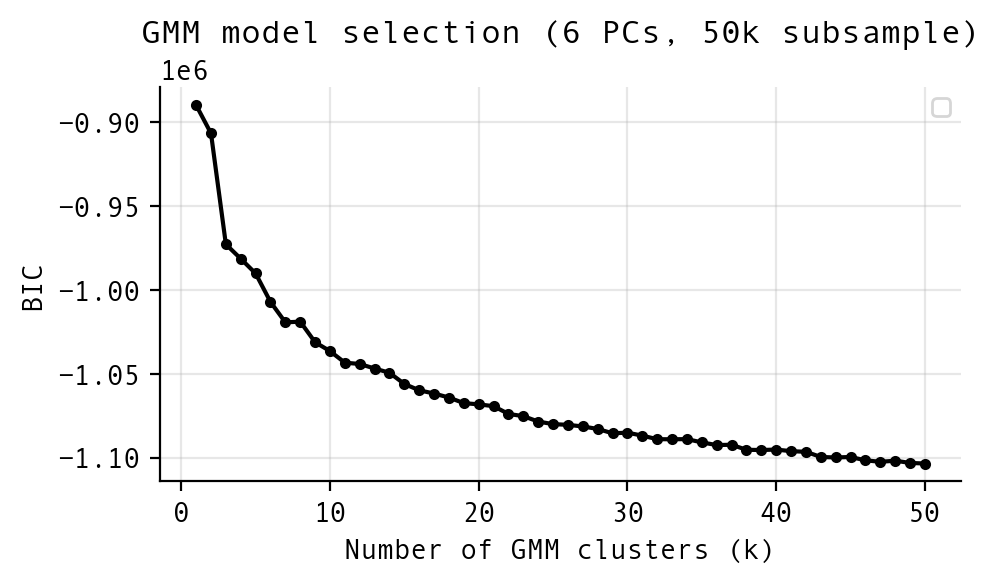

In [5]:
# BIC curve from the subsample sweep (Stage 1)
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(range(1, 51), bic_sweep, 'ko-', markersize=3)
ax.set_xlabel("Number of GMM clusters (k)")
ax.set_ylabel("BIC")
ax.set_title(f"GMM model selection ({n_dims} PCs, 50k subsample)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

The BIC decreases rapidly for the first few mixture clusters and then flattens without reaching a clear minimum. An elbow around *k* ≈ 10 marks the transition from capturing coarse density structure to merely refining the approximation — additional clusters beyond this point yield diminishing returns. This pattern indicates that the data are not well described by a small number of discrete Gaussian clusters; instead, additional clusters progressively refine the approximation of a continuous density.

Extending the search via targeted refits of the top candidates, BIC reaches its minimum at *k* ≈ 50 — requiring roughly 50 equally-sized Gaussian clusters to approximate the density, with silhouette scores near zero (0.006 at best). All clusters are active and balanced in size (each capturing 2–5% of frames), with no tiny or empty clusters. This is consistent with many overlapping clusters tiling a continuous manifold rather than capturing discrete groups.

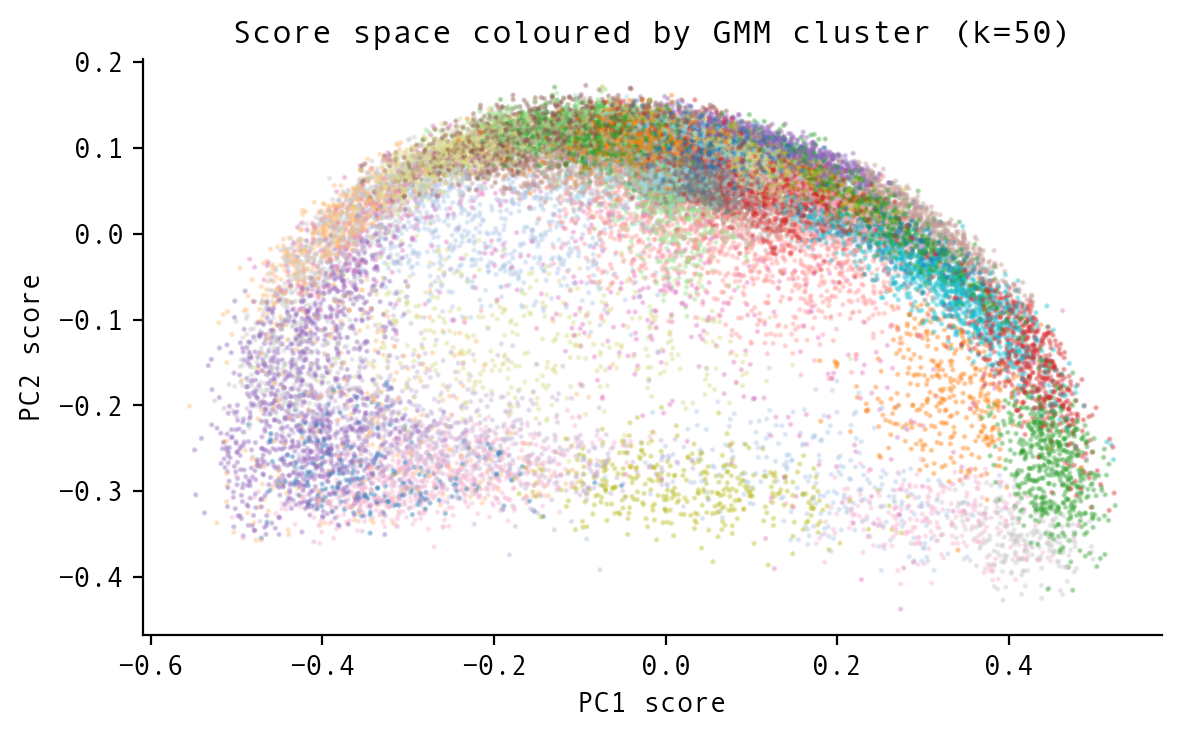

In [6]:
# PC1 vs PC2 coloured by GMM cluster assignment (best-k model)
best_k = results[0]["k"]
gmm_vis = GaussianMixture(
    n_components=best_k, covariance_type="full",
    n_init=10, max_iter=500, random_state=42
)
gmm_vis.fit(X)
labels = gmm_vis.predict(X)

# Subsample for plotting
rng = np.random.default_rng(0)
plot_idx = rng.choice(scores.shape[0], min(30_000, scores.shape[0]), replace=False)

fig, ax = plt.subplots(figsize=(6, 5))
scatter = ax.scatter(
    scores[plot_idx, 0], scores[plot_idx, 1],
    c=labels[plot_idx], cmap="tab20", s=1, alpha=0.3, rasterized=True
)
ax.set_xlabel("PC1 score")
ax.set_ylabel("PC2 score")
ax.set_title(f"Score space coloured by GMM cluster (k={best_k})")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

Projection of the score space onto the first two principal components, coloured by GMM cluster assignment (*k* ≈ 50). The mixture clusters partition the space smoothly along the manifold rather than forming isolated groups, confirming that the model approximates a continuous density rather than identifying discrete behavioural modes. This is consistent with the monotonically decreasing BIC, weak silhouette scores, and the single connected cluster found by DBSCAN.

## Silhouette Analysis

Silhouette coefficients measure how distinctly data points are separated into clusters. The coefficient ranges from -1 to +1:
- **Above ~0.5:** Indicates reasonably distinct, well-separated groups.
- **0.25 to 0.5:** Weak structure; clusters overlap substantially.
- **Below 0.25:** No meaningful cluster separation; data is diffuse.

We also compute the **Adjusted Rand Index (ARI)** between two independent GMM fits with different random seeds. ARI measures the agreement between two clusterings, adjusted for chance:
- **ARI = 1.0:** Perfect agreement -- the two fits found identical cluster assignments.
- **ARI > 0.8:** High agreement -- clusters are internally consistent across runs.
- **ARI near 0:** No better than random -- cluster assignments are unstable.

High ARI combined with low silhouette indicates that the GMM consistently partitions a smooth distribution into similar slices, but those slices do not correspond to genuinely separated groups.

In [7]:
n_dims_list = [4, 6, 9, 12]
k_values = [2, 3, 4, 5, 8, 10]

rows = []
for n_dims in n_dims_list:
    scores_subset = scores[:, :n_dims]
    for k in k_values:
        gmm1 = GaussianMixture(n_components=k, random_state=42, max_iter=200)
        labels1 = gmm1.fit_predict(scores_subset)

        gmm2 = GaussianMixture(n_components=k, random_state=123, max_iter=200)
        labels2 = gmm2.fit_predict(scores_subset)

        sil = silhouette_score(scores_subset, labels1, sample_size=5000, random_state=42)
        ari = adjusted_rand_score(labels1, labels2)

        rows.append({"PCs": n_dims, "k": k, "Silhouette": round(sil, 3), "ARI": round(ari, 3)})

sil_df = pd.DataFrame(rows)
sil_df.style.format({"Silhouette": "{:.3f}", "ARI": "{:.3f}"}).hide(axis="index")
print(sil_df)
import gc; del scores_subset, labels1, labels2, gmm1, gmm2; gc.collect();

    PCs   k  Silhouette    ARI
0     4   2       0.336  1.000
1     4   3       0.431  1.000
2     4   4       0.366  0.986
3     4   5       0.301  0.941
4     4   8       0.265  0.890
5     4  10       0.237  0.943
6     6   2       0.406  1.000
7     6   3       0.396  0.998
8     6   4       0.336  0.990
9     6   5       0.289  0.974
10    6   8       0.174  0.610
11    6  10       0.142  0.581
12    9   2       0.307  1.000
13    9   3       0.374  1.000
14    9   4       0.295  0.996
15    9   5       0.302  0.995
16    9   8       0.151  0.767
17    9  10       0.134  0.620
18   12   2       0.341  1.000
19   12   3       0.378  0.997
20   12   4       0.259  0.998
21   12   5       0.180  0.861
22   12   8       0.122  0.982
23   12  10       0.135  0.541


Silhouette coefficients are uniformly weak, well below the ~0.5 threshold for distinct clusters. At the highest tested number of GMM clusters (*k* = 10), silhouette coefficients range from 0.13 to 0.24 across all PCA dimensions, confirming no well-separated groups exist.

The Adjusted Rand Indices (ARI) between repeated fits range from 0.54 to 1.00, indicating that the GMM consistently carves the data into similar partitions. However, this consistency reflects the smoothness and regularity of the underlying distribution rather than genuine cluster separability. In other words, the GMM reliably finds the same way to slice a continuous density, but the slices do not correspond to discrete behavioural modes.

## DBSCAN Clustering

DBSCAN identifies clusters based on local density without assuming a fixed number of groups. If discrete behavioural modes existed, DBSCAN would find multiple separated clusters. We test across a range of neighbourhood sizes (epsilon).

DBSCAN's pairwise distance computation is memory-intensive in dense regions, so we use a 50,000-frame random subsample for this step (all other analyses use the full 289,528 frames).

In [8]:
# DBSCAN is O(n²) in dense regions — subsample for tractability
rng = np.random.default_rng(42)
n_dbscan = 50_000
dbscan_idx = rng.choice(scores.shape[0], size=n_dbscan, replace=False)

eps_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]
k_values = [4, 6, 9, 12]

print(f"DBSCAN on {n_dbscan:,} frame subsample")
print(f"{'k':>3} {'eps':<6} {'Clusters':>10} {'Noise %':>10}")
print("-" * 34)

for k in k_values:
    scores_kd = scores[dbscan_idx, :k]
    for eps in eps_values:
        db = DBSCAN(eps=eps, min_samples=10)
        labels = db.fit_predict(scores_kd)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct = (labels == -1).sum() / len(labels) * 100

        print(f"{k:>3} {eps:<6.1f} {n_clusters:>10} {noise_pct:>9.2f}%")
    del scores_kd, labels, db

import gc; gc.collect();

DBSCAN on 50,000 frame subsample
  k eps      Clusters    Noise %
----------------------------------


  4 0.3             1      0.00%


  4 0.4             1      0.00%


  4 0.5             1      0.00%


  4 0.6             1      0.00%


...

 12 0.5             1      0.00%


 12 0.6             1      0.00%


 12 0.7             1      0.00%


 12 0.8             1      0.00%


 12 1.0             1      0.00%


Across a wide range of neighbourhood radii (ε), DBSCAN consistently produces a **single connected cluster** with no noise points. This confirms that the shape distributions form one cohesive manifold without isolated subregions or discrete behavioural modes.

## Intrinsic Dimensionality Estimation

The Levina–Bickel nearest-neighbour method estimates the intrinsic dimensionality of the data manifold — how many independent coordinates are needed to describe the local geometry.

If the data lie on a manifold of dimension *d*, the volume of a small ball around each point grows as *r^d*. By comparing distances to the *m*-th nearest neighbour across the dataset, we estimate *d* at different scales.

In [9]:
from scipy.spatial import KDTree

def levina_bickel_dimensionality(data, m_values):
    """Estimate intrinsic dimensionality using the Levina-Bickel method."""
    tree = KDTree(data)
    n = data.shape[0]
    results = {}

    for m in m_values:
        # Get distances to m+1 nearest neighbours (first is self)
        dists, _ = tree.query(data, k=m + 1)

        # Remove self-distance
        dists = dists[:, 1:]

        # Levina-Bickel estimator
        log_ratios = np.zeros(n)
        for i in range(n):
            if dists[i, -1] > 0:
                ratios = np.log(dists[i, -1] / dists[i, :-1])
                ratios = ratios[np.isfinite(ratios)]
                if len(ratios) > 0:
                    log_ratios[i] = np.mean(ratios)

        # Remove zeros (boundary effects)
        valid = log_ratios > 0
        if valid.sum() > 0:
            d_hat = 1.0 / np.mean(log_ratios[valid])
        else:
            d_hat = np.nan

        results[m] = d_hat

    return results

scores_9d = scores[:, :9]
m_values = [5, 10, 20, 30, 40, 60]

dim_estimates = levina_bickel_dimensionality(scores_9d, m_values)

print("Intrinsic dimensionality estimates (9 PCs):")
print(f"{'m (neighbours)':<16} {'Estimated dim':>14}")
print("-" * 32)
for m, d in dim_estimates.items():
    print(f"{m:<16} {d:>14.2f}")

Intrinsic dimensionality estimates (9 PCs):
m (neighbours)    Estimated dim
--------------------------------
5                          3.45
10                         3.62
20                         3.99
30                         4.25
40                         4.41
60                         4.61


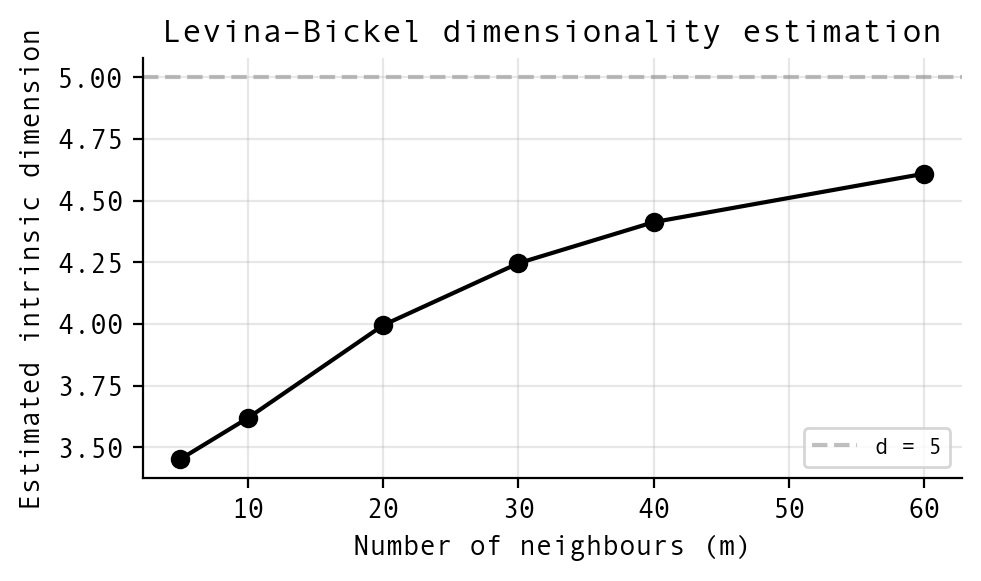

In [10]:
# Plot dimensionality estimates
fig, ax = plt.subplots(figsize=(5, 3))

ms = list(dim_estimates.keys())
ds = list(dim_estimates.values())

ax.plot(ms, ds, 'ko-', markersize=6)
ax.axhline(y=5, color='grey', linestyle='--', alpha=0.5, label='d = 5')
ax.set_xlabel("Number of neighbours (m)")
ax.set_ylabel("Estimated intrinsic dimension")
ax.set_title("Levina–Bickel dimensionality estimation")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

The estimated intrinsic dimension increases from ~3.5 at very small neighbourhoods (*m* = 5) to ~4.6 at *m* = 60, consistent with the PCA-based dimensionality estimate. The data globally conform to a manifold of approximately four to five effective dimensions.

## Summary

All four complementary analyses converge on the same conclusion: hawk flight behaviours occupy a **continuous, low-dimensional manifold** rather than forming discrete clusters or gaits.

| Method | Finding |
|--------|---------|
| **GMM (BIC)** | BIC minimum at *k* ≈ 50 with ~50 balanced, overlapping clusters tiling the space (silhouette ≈ 0.006); no minimum at small *k* |
| **Silhouette** | At *k* = 10: coefficients of 0.13–0.24, far below the ~0.5 threshold for distinct groups |
| **DBSCAN** | Single connected cluster at all tested scales; 0.00% noise |
| **Intrinsic dimensionality** | ~4–5 effective dimensions, consistent across local and global scales |

Rather than switching between discrete states, hawks modulate their wing and tail configurations **smoothly** within a shared morphing space. The morphing shape modes provide a continuous coordinate system that faithfully describes this smooth variation.

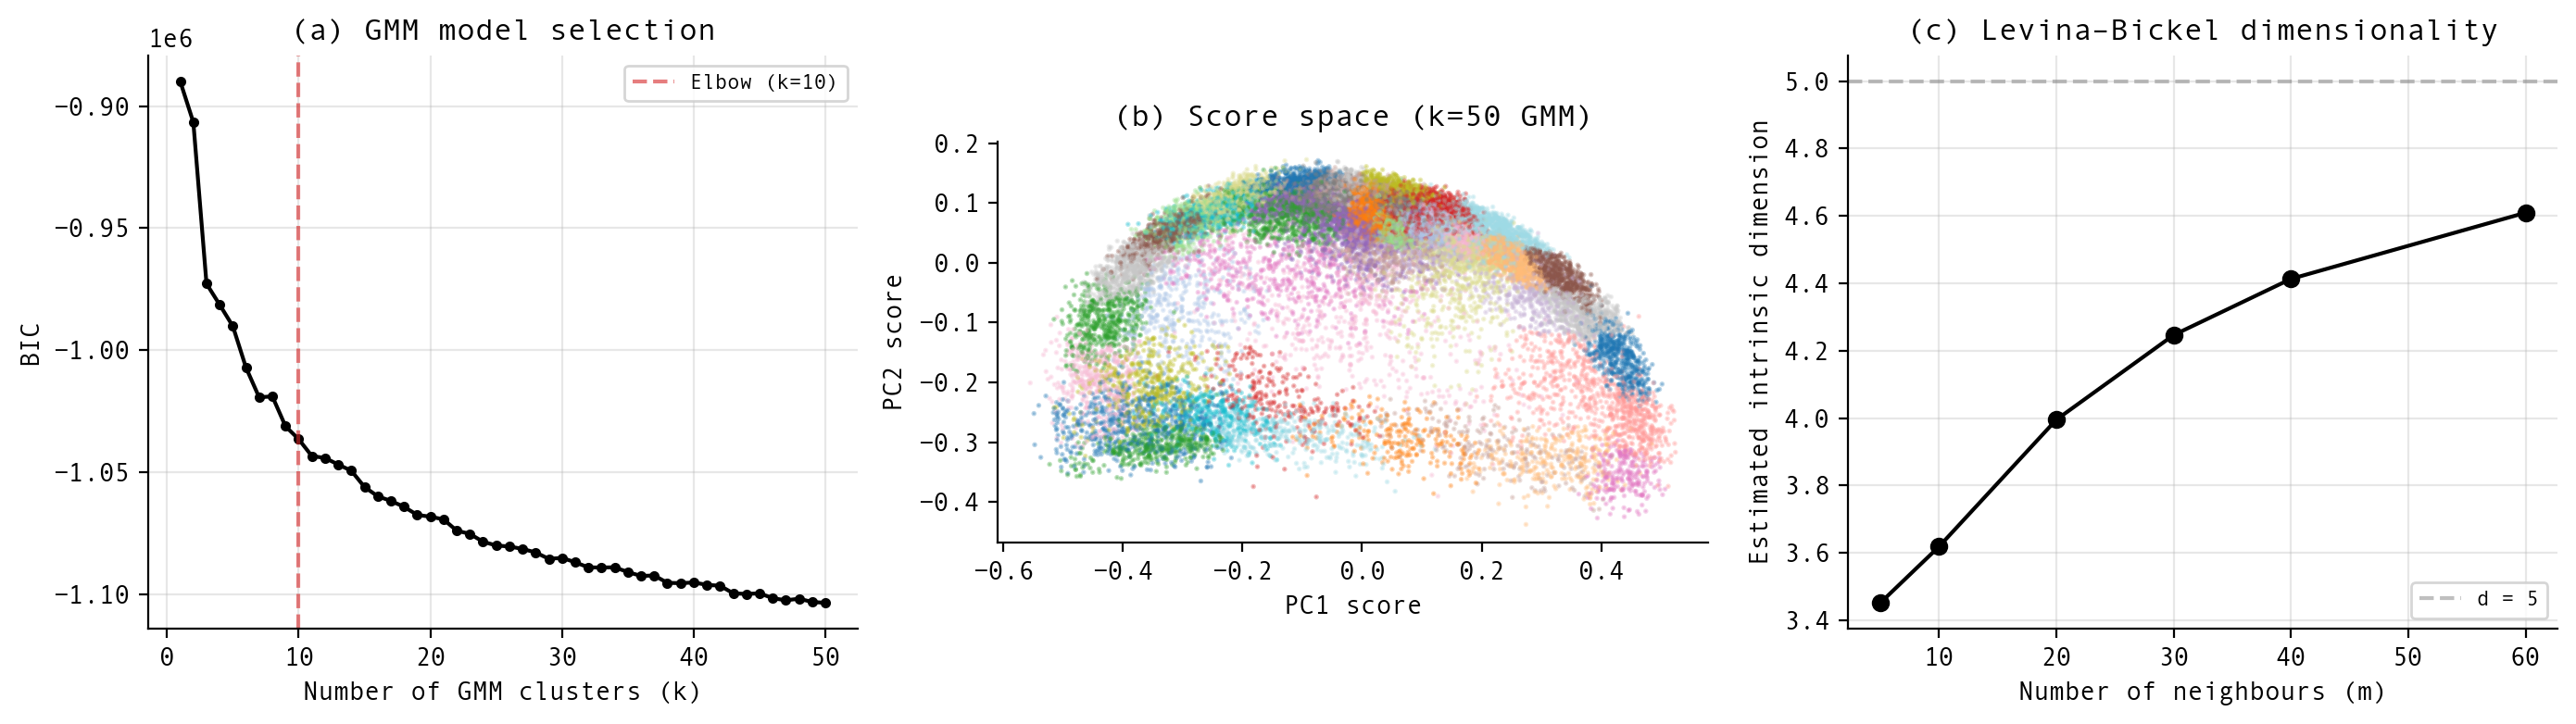

Saved: figures/supplementary/S13_continuum_summary.pdf


In [11]:
# Composite summary figure: (a) BIC curve, (b) GMM scatter, (c) intrinsic dimensionality
from sklearn.mixture import GaussianMixture

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (a) BIC curve with elbow marker
ax = axes[0]
ax.plot(range(1, 51), bic_sweep, 'ko-', markersize=3)
# Mark the elbow at k≈10
elbow_k = 10
ax.axvline(x=elbow_k, color='tab:red', linestyle='--', alpha=0.6, label=f'Elbow (k={elbow_k})')
ax.set_xlabel("Number of GMM clusters (k)")
ax.set_ylabel("BIC")
ax.set_title("(a) GMM model selection")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# (b) PC1 vs PC2 coloured by GMM cluster
ax = axes[1]
best_k = np.argmin(bic_sweep) + 1
gmm_plot = GaussianMixture(n_components=best_k, random_state=42).fit(scores[:, :4])
labels = gmm_plot.predict(scores[:, :4])

rng_plot = np.random.default_rng(0)
plot_idx = rng_plot.choice(scores.shape[0], min(30_000, scores.shape[0]), replace=False)
ax.scatter(
    scores[plot_idx, 0], scores[plot_idx, 1],
    c=labels[plot_idx], cmap="tab20", s=1, alpha=0.3, rasterized=True
)
ax.set_xlabel("PC1 score")
ax.set_ylabel("PC2 score")
ax.set_title(f"(b) Score space (k={best_k} GMM)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_aspect("equal")

del gmm_plot, labels

# (c) Intrinsic dimensionality
ax = axes[2]
ms = list(dim_estimates.keys())
ds = list(dim_estimates.values())
ax.plot(ms, ds, 'ko-', markersize=6)
ax.axhline(y=5, color='grey', linestyle='--', alpha=0.5, label='d = 5')
ax.set_xlabel("Number of neighbours (m)")
ax.set_ylabel("Estimated intrinsic dimension")
ax.set_title("(c) Levina–Bickel dimensionality")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("../../figures/supplementary/S13_continuum_summary.pdf", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: figures/supplementary/S13_continuum_summary.pdf")

---

## References

- Levina, E. & Bickel, P. J. (2004). Maximum likelihood estimation of intrinsic dimension. *Advances in Neural Information Processing Systems*, 17, 777–784.
- Stephens, G. J., Johnson-Kerner, B., Bialek, W. & Ryu, W. S. (2008). Dimensionality and dynamics in the behavior of *C. elegans*. *PLOS Computational Biology*, 4, e1000028.